In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

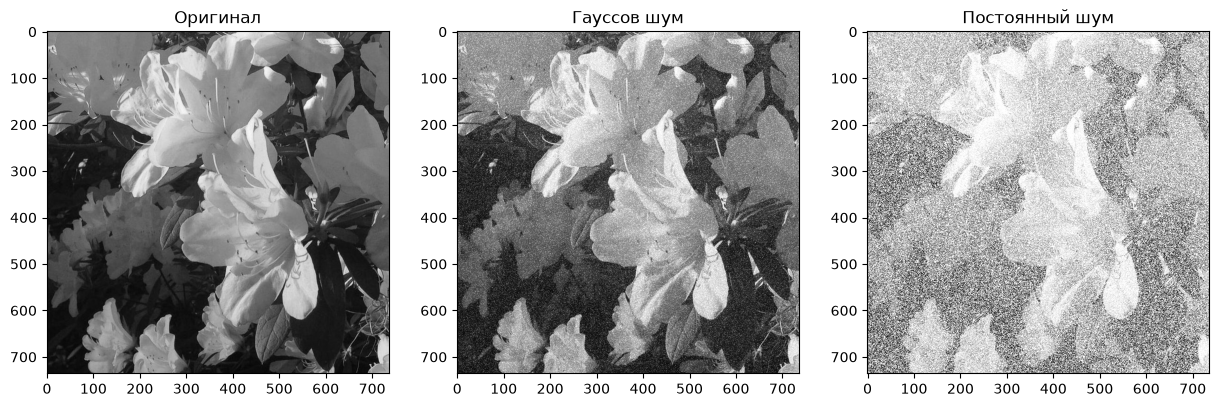

In [4]:
image = cv2.imread('flowers.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

mean = 0
stddev = 50 
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

low = -50
high = 50
uniform_noise = np.random.uniform(low, high, image_gray.shape)

image_noise_uniform = cv2.add(image_gray, uniform_noise.astype(np.uint8)) 

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(image_gray, cmap='gray'), plt.title('Оригинал')
plt.subplot(1, 3, 2), plt.imshow(image_noise_gauss, cmap='gray'), plt.title('Гауссов шум')
plt.subplot(1, 3, 3), plt.imshow(image_noise_uniform, cmap='gray'), plt.title('Постоянный шум')
plt.show()

In [6]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
def evaluate_filter(original, filtered, name):
    mse_val = mse(original, filtered)
    ssim_val = ssim(original, filtered)
    print(f"{name}: MSE = {mse_val:.2f}, SSIM = {ssim_val:.4f}")
    return mse_val, ssim_val
print("--- Результаты для Гауссова шума ---")

median_gauss = cv2.medianBlur(image_noise_gauss, 5)
evaluate_filter(image_gray, median_gauss, "Медианный (k=5)")

gaussian_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
evaluate_filter(image_gray, gaussian_gauss, "Гауссов (5x5)")

bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
evaluate_filter(image_gray, bilateral_gauss, "Билатеральный (d=9)")

nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, None, h=10, templateWindowSize=7, searchWindowSize=21)
evaluate_filter(image_gray, nlm_gauss, "NLM (h=10)")

print("\n--- Результаты для Постоянного шума ---")

median_noise_uniform = cv2.medianBlur(image_noise_uniform, 5)
evaluate_filter(image_gray, median_noise_uniform, "Медианный (k=5)")

gaussian_noise_uniform = cv2.GaussianBlur(image_noise_uniform, (5, 5), 0)
evaluate_filter(image_gray, gaussian_noise_uniform, "Гауссов (5x5)")

bilateral_noise_uniform = cv2.bilateralFilter(image_noise_uniform, 9, 75, 75)
evaluate_filter(image_gray, bilateral_noise_uniform, "Билатеральный (d=9)")

nlm_noise_uniform = cv2.fastNlMeansDenoising(image_noise_uniform, None, h=10, templateWindowSize=7, searchWindowSize=21)
evaluate_filter(image_gray, nlm_noise_uniform, "NLM (h=10)")

--- Результаты для Гауссова шума ---
Медианный (k=5): MSE = 202.78, SSIM = 0.6865
Гауссов (5x5): MSE = 479.66, SSIM = 0.6480
Билатеральный (d=9): MSE = 415.52, SSIM = 0.6744
NLM (h=10): MSE = 1155.09, SSIM = 0.2582

--- Результаты для Постоянного шума ---
Медианный (k=5): MSE = 13100.19, SSIM = 0.1085
Гауссов (5x5): MSE = 8895.62, SSIM = 0.2759
Билатеральный (d=9): MSE = 12013.26, SSIM = 0.1723
NLM (h=10): MSE = 13613.51, SSIM = 0.0907


(np.float64(13613.512124881852), np.float64(0.090737980274547))

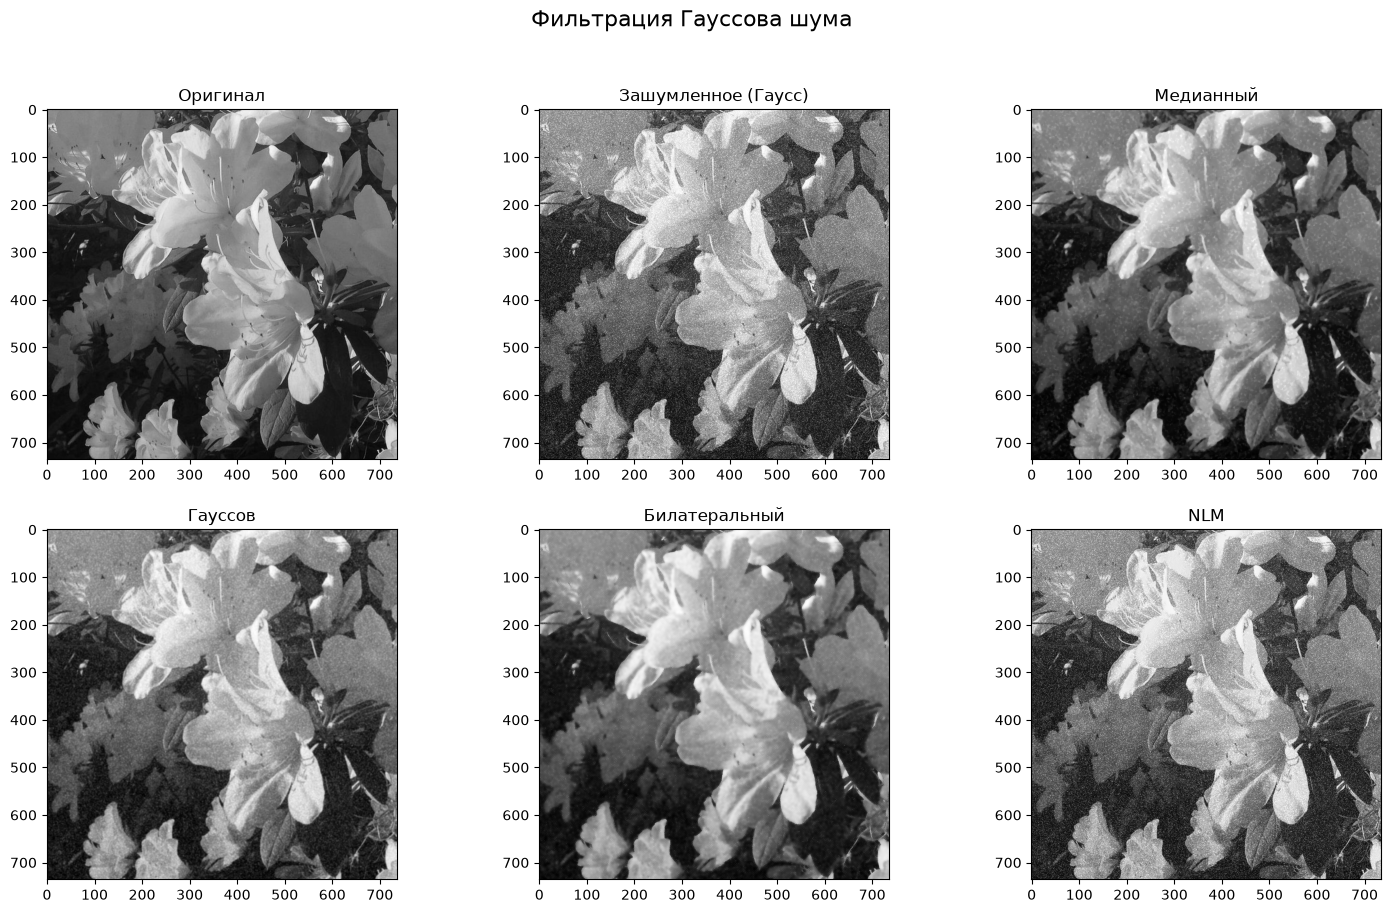

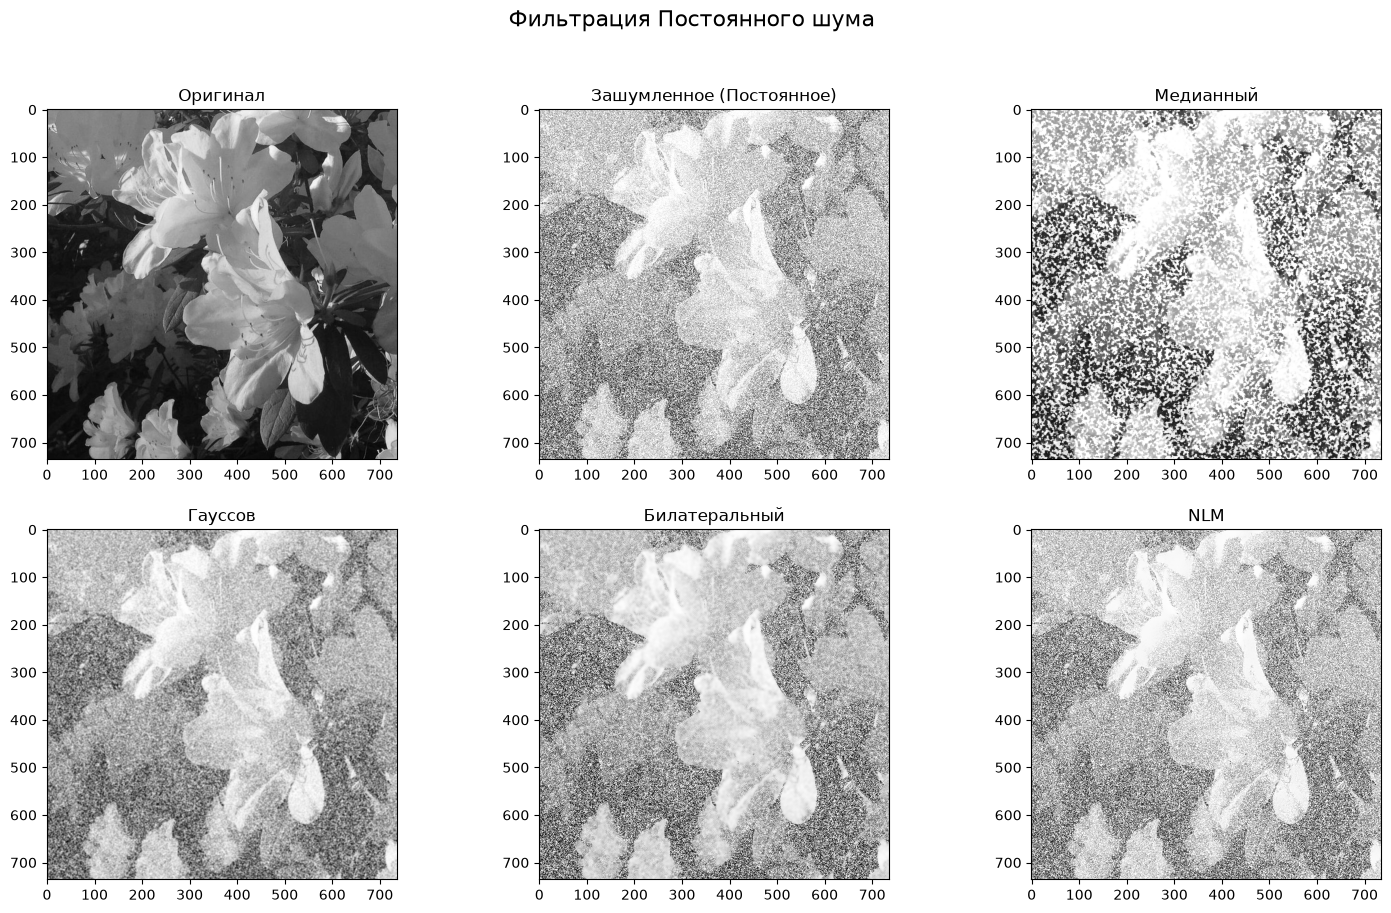

In [8]:
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1), plt.imshow(image_gray, cmap='gray'), plt.title('Оригинал')
plt.subplot(2, 3, 2), plt.imshow(image_noise_gauss, cmap='gray'), plt.title('Зашумленное (Гаусс)')
plt.subplot(2, 3, 3), plt.imshow(median_gauss, cmap='gray'), plt.title('Медианный')
plt.subplot(2, 3, 4), plt.imshow(gaussian_gauss, cmap='gray'), plt.title('Гауссов')
plt.subplot(2, 3, 5), plt.imshow(bilateral_gauss, cmap='gray'), plt.title('Билатеральный')
plt.subplot(2, 3, 6), plt.imshow(nlm_gauss, cmap='gray'), plt.title('NLM')
plt.suptitle('Фильтрация Гауссова шума', fontsize=16)
plt.show()

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1), plt.imshow(image_gray, cmap='gray'), plt.title('Оригинал')
plt.subplot(2, 3, 2), plt.imshow(image_noise_uniform, cmap='gray'), plt.title('Зашумленное (Постоянное)')
plt.subplot(2, 3, 3), plt.imshow(median_noise_uniform, cmap='gray'), plt.title('Медианный')
plt.subplot(2, 3, 4), plt.imshow(gaussian_noise_uniform, cmap='gray'), plt.title('Гауссов')
plt.subplot(2, 3, 5), plt.imshow(bilateral_noise_uniform, cmap='gray'), plt.title('Билатеральный')
plt.subplot(2, 3, 6), plt.imshow(nlm_noise_uniform, cmap='gray'), plt.title('NLM')
plt.suptitle('Фильтрация Постоянного шума', fontsize=16)
plt.show()

In [9]:
#по метрикам и при визуальном осмотре лучший результат показали 
#медианный фильтр при гауссовом шуме, гауссов фильтр при постоянном шуме 
